### Imports and utils

In [1]:
import optuna
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from plot_matplotlib import plot

In [2]:
def get_fg_pp_columns(df):
    physical_properties_columns = []
    functional_group_columns = []
    for col in df.columns:
        if("fr_" in col):
            functional_group_columns.append(col)
        else:
            physical_properties_columns.append(col)
    return functional_group_columns, physical_properties_columns

### Load and split data

In [3]:
df_train = pd.read_csv("train_data.csv")
df_test = pd.read_csv("test_data.csv")
df_test

,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,MaxPartialCharge,MinPartialCharge,...,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,SMILES,LogIpc,LogKappa3
0,12.878086,0.135166,-3.613531,0.804765,23.400000,395.958,405.938848,108,0.300387,-0.487304,...,0,1,0,0,0,0,0,CC(C)Oc1c(Br)c(Br)n(C)c1C(=O)N=c1nn[nH][nH]1,14.952236,1.047229
1,14.850670,2.601961,-5.888852,0.537787,85.800000,384.258,418.235539,166,0.305439,-0.457547,...,0,0,0,0,0,0,0,CCC(=O)OCC(=O)C1(O)CCC2C3CC=C4CC(=O)CCC4(C)C3C...,27.967113,1.077218
2,12.898394,0.127949,-0.952873,0.462219,17.238095,395.997,403.915987,104,0.249805,-0.618157,...,0,0,0,0,0,0,0,[O-][n+]1ccnc(-c2ccc(Br)cc2)c1-c1ccc(Br)cc1,15.279075,1.093972
3,12.901652,2.166399,-5.983449,0.599454,106.642857,356.248,390.240624,156,0.314361,-0.434269,...,0,0,0,0,0,0,0,CC12CCC(O)CC1CCC1C2CCC2(C)C(C3=COC(=O)C3)C(O)C...,27.564991,0.844890
4,8.818441,0.418935,-2.713642,0.440550,87.611111,384.280,385.816009,100,0.166497,-0.367569,...,0,0,0,0,0,0,0,ClC1=C(Cl)C2(Cl)C3C4OC4C(Cl)C3C1(Cl)C2(Cl)Cl,11.459630,0.020404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2625,12.552000,0.588432,-3.942702,0.331576,25.380952,479.842,487.821808,116,0.268945,-0.394123,...,0,0,0,0,0,0,0,O=C(NC(CO)C(O)c1ccc([N+](=O)[O-])cc1)C(Br)(Br)Br,14.638889,1.666423
2626,13.584207,0.042767,-6.978536,0.182795,28.727273,482.459,511.126934,180,0.305135,-0.505717,...,0,0,1,0,0,0,0,O=c1[nH]c2c(O)ccc(CCNCCCS(=O)(=O)NCCOCCSc3cccc...,27.900448,2.170394
2627,14.225166,0.029025,-4.659959,0.166576,42.052632,556.482,582.113744,204,0.335692,-0.427452,...,0,1,1,0,0,0,0,Cn1nnnc1SC=C1CSC2C(NC(=O)Cc3csc(=N)[nH]3)C(=O)...,28.873676,1.807969
2628,14.143610,0.052066,-4.606425,0.200510,41.513514,544.471,568.098093,198,0.335692,-0.427452,...,0,1,0,0,0,0,0,Cc1nnc(SC=C2CSC3C(NC(=O)Cn4cnnn4)C(=O)N3C2C(=O...,27.621105,1.835786


In [4]:
df_train, df_val = train_test_split(df_train, test_size=0.3, random_state=42)


x_train = df_train.drop(labels=["LogP","SMILES"],axis=1)
y_train = df_train["LogP"]

x_val = df_val.drop(labels=["LogP","SMILES"],axis=1)
y_val = df_val["LogP"]

x_test = df_test.drop(labels=["SMILES"],axis=1)

### Features engineering

Drop out columns of functional groups since they are categorical features and can create noise for SVR

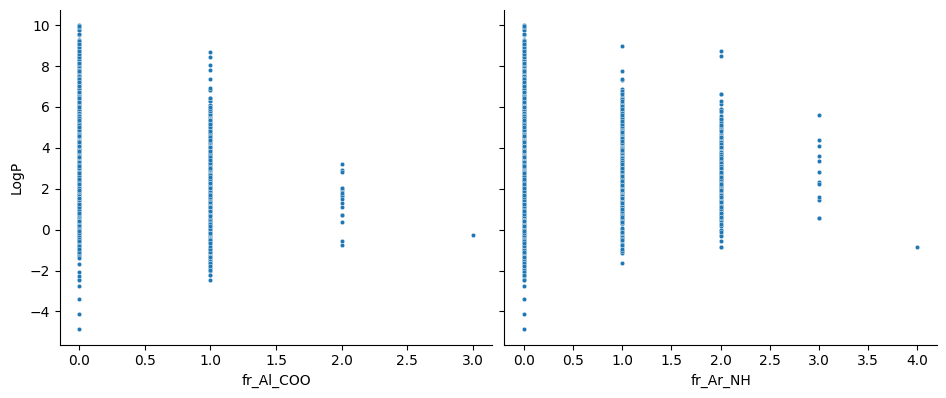

In [5]:
fg_columns, pp_columns = get_fg_pp_columns(x_train)
sns.pairplot(data=df_train[["fr_Al_COO","fr_Ar_NH", "LogP"]], x_vars=["fr_Al_COO","fr_Ar_NH"], y_vars=["LogP"], plot_kws={"s": 10}, height=4,aspect=1.2)

In [6]:
x_train = x_train[pp_columns]
x_val = x_val[pp_columns]
x_test = x_test[pp_columns]

Many of the remaining features have a skew. Apply Yeo-Johnson transformation to normalize distributions

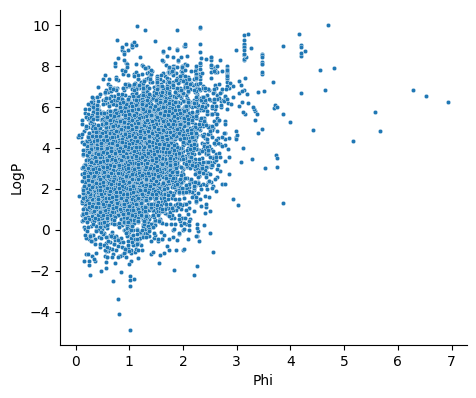

In [7]:
fg_columns, pp_columns = get_fg_pp_columns(x_train)
sns.pairplot(data=df_train[["Phi","LogP"]], x_vars=["Phi"], y_vars=["LogP"], plot_kws={"s": 10}, height=4,aspect=1.2)

In [8]:
scaler = PowerTransformer(method="yeo-johnson").set_output(transform="pandas")
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

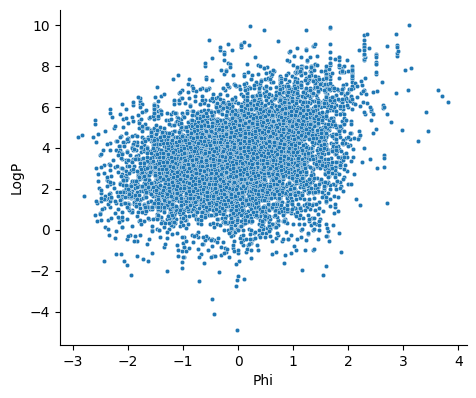

In [9]:
plot_df = pd.concat([x_train,y_train], axis=1)
sns.pairplot(data=plot_df[["Phi","LogP"]], x_vars=["Phi"], y_vars=["LogP"], plot_kws={"s": 10}, height=4,aspect=1.2)

Features can be a linear combination of each other. PCA get rid of them. Also shrink the feature space leaving the components describing 99% of the variance.

99.1%


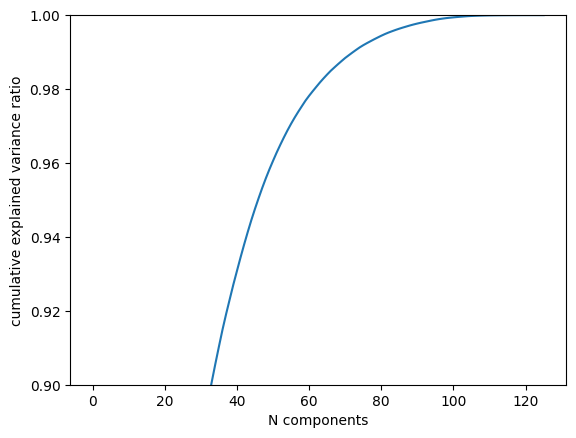

In [10]:
pca = PCA()
pca.fit(x_train)
cumulative_evr = [ sum(pca.explained_variance_ratio_[:i]) for i in range(1,len(pca.explained_variance_ratio_))]

fig, axe = plt.subplots()
axe.plot(cumulative_evr)
axe.set_ylim(0.9,1)
axe.set_ylabel("cumulative explained variance ratio")
axe.set_xlabel("N components")
print(f"{100*cumulative_evr[73]:.1f}%")


In [11]:
pca = PCA(n_components=73)
pca.fit(x_train)
x_train = pca.transform(x_train)
x_val = pca.transform(x_val)
x_test = pca.transform(x_test)

### Hyperparameters selection

In [ ]:
def objective(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 1e3, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.01, 0.2),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly']),
        'gamma': trial.suggest_float('gamma', 1e-4, 1e1, log=True),
    }
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)

    model = SVR(**params)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_val)
    return root_mean_squared_error(y_val, y_pred)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(objective, n_trials=200, timeout=3600, n_jobs=-1)

trial = study.best_trial

print("Best trial:")
print(f"RMSE: {trial.value:.4f}")
print(f"Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

In [12]:
def objective(trial):
    params = {
        'C': trial.suggest_float('C', 10, 15, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.1, 0.5),
        'kernel': trial.suggest_categorical('kernel', ['rbf']),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
    }

    model = SVR(**params)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_val)
    return root_mean_squared_error(y_val, y_pred)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(objective, n_trials=30, timeout=3600, n_jobs=-1)

trial = study.best_trial

print("Best trial:")
print(f"RMSE: {trial.value:.4f}")
print(f"Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-04-30 22:48:07,836] A new study created in memory with name: no-name-9656b028-67cc-40d7-9588-2b9e453cd2f7
[I 2025-04-30 22:48:17,711] Trial 9 finished with value: 0.7456908612305675 and parameters: {'C': 13.233192680371138, 'epsilon': 0.49747550451377454, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 9 with value: 0.7456908612305675.
[I 2025-04-30 22:48:20,626] Trial 1 finished with value: 0.7181635939885966 and parameters: {'C': 13.518684248102316, 'epsilon': 0.43005875749964495, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 1 with value: 0.7181635939885966.
[I 2025-04-30 22:48:23,221] Trial 2 finished with value: 0.7116928498136667 and parameters: {'C': 11.921920973207435, 'epsilon': 0.36689889966917877, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 2 with value: 0.7116928498136667.
[I 2025-04-30 22:48:31,235] Trial 8 finished with value: 0.7327665629178257 and parameters: {'C': 12.716005294937641, 'epsilon': 0.27848920425154566, 'kernel': 'rbf', 'gamma': 'auto'}. 

Best trial:
RMSE: 0.7082
Params: 
    C: 12.833675102691164
    epsilon: 0.19530787065408411
    kernel: rbf
    gamma: scale


In [14]:
optuna.visualization.plot_param_importances(study)

In [15]:
best_model = SVR(C=12.833675102691164, epsilon=0.19530787065408411,kernel= "rbf",gamma= "scale")

best_model.fit(x_train, y_train)
train_preds = best_model.predict(x_train)
val_preds = best_model.predict(x_val)

train_rmse = root_mean_squared_error(y_train, train_preds)
val_rmse = root_mean_squared_error(y_val, val_preds)
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Validate RMSE: {val_rmse:.2f}")


Train RMSE: 0.36
Validate RMSE: 0.71


### Plot results

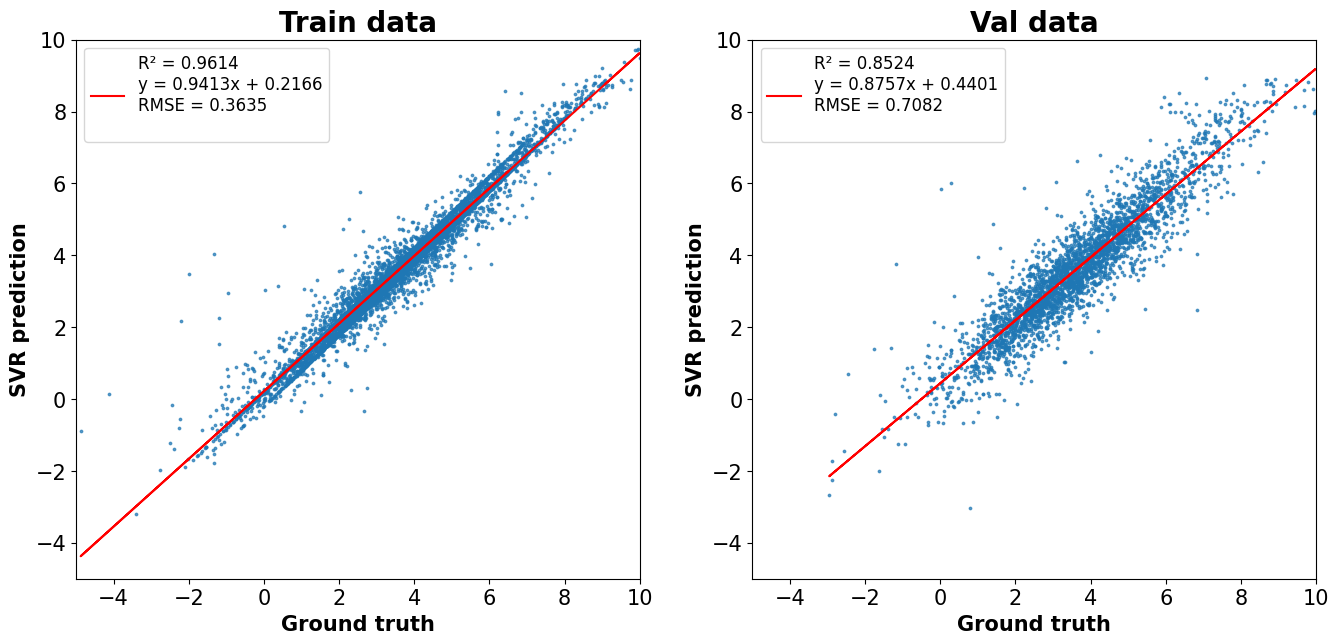

In [16]:
plot(y_val, val_preds, y_train, train_preds, axis_lims=[-5, 10, -5, 10])